# Dataset Partitioning Functions Test

This notebook validates the three dataset partitioning strategies:
1. **IID**: Random shuffling (baseline, least heterogeneous)
2. **By Day**: Temporal partitioning (naturally non-IID)
3. **By Attack Family**: Specialized partitioning (highly non-IID)

Each test includes label distribution analysis and EMD computation.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Import dataset functions
from dataset import (
    partition_iid, 
    partition_by_day, 
    partition_by_attack_family,
    compute_emd,
    analyze_partitions
)

print("✓ Dataset module imported successfully")

/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


✓ Dataset module imported successfully


In [2]:
# Create synthetic test dataset (CICIDS2017-like)
np.random.seed(42)

n_samples = 10000

# Generate timestamps
timestamps = pd.date_range('2017-07-03', periods=n_samples, freq='5min')

# Generate synthetic data
synthetic_data = pd.DataFrame({
    'Timestamp': timestamps,
    'Label': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]),  # 80% normal, 20% attack
    'Flow_Bytes/s': np.random.exponential(100, n_samples),
    'Flow_Packets/s': np.random.exponential(10, n_samples),
    'Duration': np.random.exponential(5, n_samples),
    'Fwd_Packets': np.random.exponential(3, n_samples),
    'Bwd_Packets': np.random.exponential(3, n_samples),
})

print(f"✓ Synthetic dataset created: {synthetic_data.shape}")
print(f"  Shape: {synthetic_data.shape}")
print(f"  Labels: {synthetic_data['Label'].value_counts().to_dict()}")
print(f"\nFirst few rows:")
print(synthetic_data.head())

✓ Synthetic dataset created: (10000, 7)
  Shape: (10000, 7)
  Labels: {0: 8038, 1: 1962}

First few rows:
            Timestamp  Label  Flow_Bytes/s  Flow_Packets/s   Duration  \
0 2017-07-03 00:00:00      0     46.783130       13.093271   5.082553   
1 2017-07-03 00:05:00      1     40.483345        2.039686   3.074384   
2 2017-07-03 00:10:00      0     19.377155        4.256265  16.690905   
3 2017-07-03 00:15:00      0     93.462445       10.885054   1.235763   
4 2017-07-03 00:20:00      0     64.745545        6.579525   4.431917   

   Fwd_Packets  Bwd_Packets  
0     1.065366     5.636594  
1     0.298857     2.046723  
2     0.405258     0.652475  
3     0.597809     4.002720  
4     0.683162     1.627352  


## Test 1: IID Partitioning

**IID (Independent and Identically Distributed)**: Baseline partitioning strategy.

**How it works:**
1. Randomly shuffle all data
2. Split equally among N clients
3. Each client gets ~1/N of samples with same label distribution as full dataset

**Key properties:**
- **Homogeneous**: All clients have similar data (same attack distribution)
- **Easy convergence**: FedAvg performs well (no heterogeneity challenges)
- **Unrealistic**: Real organizations have different attack patterns
- **EMD score**: Low (~0.007), indicates homogeneity

**Expected results:**
- All clients: ~80% benign, ~20% attacks (matches overall distribution)
- Training converges quickly
- Federated equals centralized performance

In [3]:
print("="*70)
print("TEST 1: IID PARTITIONING")
print("="*70)

# Run IID partition
iid_clients = partition_iid(synthetic_data, n_clients=5, seed=42)

print(f"\n✓ Created {len(iid_clients)} IID clients")
print(f"\nClient sizes and label distribution:")

iid_stats = []
for i, client_df in enumerate(iid_clients):
    n_total = len(client_df)
    n_positive = (client_df['Label'] == 1).sum()
    n_negative = (client_df['Label'] == 0).sum()
    pos_ratio = n_positive / n_total * 100
    
    iid_stats.append({
        'Client': i,
        'Total': n_total,
        'Positive': n_positive,
        'Negative': n_negative,
        'Positive %': f"{pos_ratio:.1f}%"
    })
    
    print(f"  Client {i}: {n_total:5d} samples | "
          f"Positive: {n_positive:4d} ({pos_ratio:.1f}%) | "
          f"Negative: {n_negative:4d}")

print("\nExpected for IID: All clients should have ~20% positive, ~80% negative")

INFO:dataset:Client 0: 2000 samples (pos: 395, neg: 1605)
INFO:dataset:Client 1: 2000 samples (pos: 373, neg: 1627)
INFO:dataset:Client 2: 2000 samples (pos: 404, neg: 1596)
INFO:dataset:Client 3: 2000 samples (pos: 392, neg: 1608)
INFO:dataset:Client 4: 2000 samples (pos: 398, neg: 1602)
INFO:dataset:IID partition created: 5 clients


TEST 1: IID PARTITIONING

✓ Created 5 IID clients

Client sizes and label distribution:
  Client 0:  2000 samples | Positive:  395 (19.8%) | Negative: 1605
  Client 1:  2000 samples | Positive:  373 (18.6%) | Negative: 1627
  Client 2:  2000 samples | Positive:  404 (20.2%) | Negative: 1596
  Client 3:  2000 samples | Positive:  392 (19.6%) | Negative: 1608
  Client 4:  2000 samples | Positive:  398 (19.9%) | Negative: 1602

Expected for IID: All clients should have ~20% positive, ~80% negative


In [4]:
# Compute EMD for IID partition
print("\nComputing EMD for IID partition...")
iid_emd = compute_emd(iid_clients)

print(f"\nEMD Statistics:")
emd_values = iid_emd[np.triu_indices_from(iid_emd, k=1)]
print(f"  Mean EMD: {emd_values.mean():.4f} (should be LOW for IID)")
print(f"  Max EMD:  {emd_values.max():.4f}")
print(f"  Min EMD:  {emd_values.min():.4f}")

print("\nEMD Matrix (lower = more similar distributions):")
print(iid_emd.round(4))

INFO:dataset:Client 0 label distribution: {0: np.float64(0.8025), 1: np.float64(0.1975)}
INFO:dataset:Client 1 label distribution: {0: np.float64(0.8135), 1: np.float64(0.1865)}
INFO:dataset:Client 2 label distribution: {0: np.float64(0.798), 1: np.float64(0.202)}
INFO:dataset:Client 3 label distribution: {0: np.float64(0.804), 1: np.float64(0.196)}
INFO:dataset:Client 4 label distribution: {0: np.float64(0.801), 1: np.float64(0.199)}
INFO:dataset:EMD Matrix:
[[0.     0.011  0.0045 0.0015 0.0015]
 [0.011  0.     0.0155 0.0095 0.0125]
 [0.0045 0.0155 0.     0.006  0.003 ]
 [0.0015 0.0095 0.006  0.     0.003 ]
 [0.0015 0.0125 0.003  0.003  0.    ]]



Computing EMD for IID partition...

EMD Statistics:
  Mean EMD: 0.0068 (should be LOW for IID)
  Max EMD:  0.0155
  Min EMD:  0.0015

EMD Matrix (lower = more similar distributions):
[[0.     0.011  0.0045 0.0015 0.0015]
 [0.011  0.     0.0155 0.0095 0.0125]
 [0.0045 0.0155 0.     0.006  0.003 ]
 [0.0015 0.0095 0.006  0.     0.003 ]
 [0.0015 0.0125 0.003  0.003  0.    ]]


## Test 2: Day-Based Partitioning

**Temporal partitioning**: Split by day of week.

**How it works:**
1. Group samples by day (Monday, Tuesday, ..., Sunday)
2. Each day becomes one client's dataset
3. Attack patterns naturally vary by day (temporal heterogeneity)

**Key properties:**
- **Semi-realistic**: Organizations see time-varying attacks
- **Moderate heterogeneity**: Some days quieter, some busier
- **EMD score**: Medium (~0.012), more heterogeneous than IID
- **Temporal correlation**: Same organization produces different attacks at different times

**Expected results:**
- Different clients have different attack percentages
- Some days attacked more than others
- Federated convergence slower than IID but faster than family-based

In [5]:
print("\n" + "="*70)
print("TEST 2: DAY-BASED PARTITIONING")
print("="*70)

# Add some day-specific attack patterns to synthetic data
df_with_patterns = synthetic_data.copy()

# Get day of week from timestamp
df_with_patterns['DayOfWeek'] = df_with_patterns['Timestamp'].dt.dayofweek

# Make different days have different attack rates
for day in df_with_patterns['DayOfWeek'].unique():
    day_mask = df_with_patterns['DayOfWeek'] == day
    attack_rate = 0.1 + (day * 0.05)  # Vary attack rate: 10-35%
    n_to_flip = int((day_mask.sum() * attack_rate) - (df_with_patterns[day_mask]['Label'].sum()))
    
    if n_to_flip > 0:
        flip_indices = np.random.choice(
            df_with_patterns[day_mask & (df_with_patterns['Label'] == 0)].index,
            min(n_to_flip, (day_mask & (df_with_patterns['Label'] == 0)).sum()),
            replace=False
        )
        df_with_patterns.loc[flip_indices, 'Label'] = 1

print("✓ Created dataset with day-specific attack patterns")

# Run day-based partition
day_clients = partition_by_day(df_with_patterns, n_clients=5)

print(f"\n✓ Created {len(day_clients)} day-based clients")
print(f"\nClient sizes and label distribution:")

day_stats = []
for i, client_df in enumerate(day_clients):
    n_total = len(client_df)
    n_positive = (client_df['Label'] == 1).sum()
    n_negative = (client_df['Label'] == 0).sum()
    pos_ratio = n_positive / n_total * 100
    
    day_stats.append({
        'Client': i,
        'Total': n_total,
        'Positive': n_positive,
        'Negative': n_negative,
        'Positive %': f"{pos_ratio:.1f}%"
    })
    
    print(f"  Client {i}: {n_total:5d} samples | "
          f"Positive: {n_positive:4d} ({pos_ratio:.1f}%) | "
          f"Negative: {n_negative:4d}")

print("\nExpected for Day-based: Different positive ratios per day")

INFO:dataset:Found 35 unique days: [datetime.date(2017, 7, 3), datetime.date(2017, 7, 4), datetime.date(2017, 7, 5), datetime.date(2017, 7, 6), datetime.date(2017, 7, 7), datetime.date(2017, 7, 8), datetime.date(2017, 7, 9), datetime.date(2017, 7, 10), datetime.date(2017, 7, 11), datetime.date(2017, 7, 12), datetime.date(2017, 7, 13), datetime.date(2017, 7, 14), datetime.date(2017, 7, 15), datetime.date(2017, 7, 16), datetime.date(2017, 7, 17), datetime.date(2017, 7, 18), datetime.date(2017, 7, 19), datetime.date(2017, 7, 20), datetime.date(2017, 7, 21), datetime.date(2017, 7, 22), datetime.date(2017, 7, 23), datetime.date(2017, 7, 24), datetime.date(2017, 7, 25), datetime.date(2017, 7, 26), datetime.date(2017, 7, 27), datetime.date(2017, 7, 28), datetime.date(2017, 7, 29), datetime.date(2017, 7, 30), datetime.date(2017, 7, 31), datetime.date(2017, 8, 1), datetime.date(2017, 8, 2), datetime.date(2017, 8, 3), datetime.date(2017, 8, 4), datetime.date(2017, 8, 5), datetime.date(2017, 8, 6


TEST 2: DAY-BASED PARTITIONING
✓ Created dataset with day-specific attack patterns

✓ Created 5 day-based clients

Client sizes and label distribution:
  Client 0:  2016 samples | Positive:  580 (28.8%) | Negative: 1436
  Client 1:  2016 samples | Positive:  542 (26.9%) | Negative: 1474
  Client 2:  2016 samples | Positive:  538 (26.7%) | Negative: 1478
  Client 3:  2016 samples | Positive:  542 (26.9%) | Negative: 1474
  Client 4:  1936 samples | Positive:  500 (25.8%) | Negative: 1436

Expected for Day-based: Different positive ratios per day


In [6]:
# Compute EMD for day-based partition
print("\nComputing EMD for day-based partition...")
day_emd = compute_emd(day_clients)

print(f"\nEMD Statistics:")
emd_values = day_emd[np.triu_indices_from(day_emd, k=1)]
print(f"  Mean EMD: {emd_values.mean():.4f} (should be MEDIUM for day-based)")
print(f"  Max EMD:  {emd_values.max():.4f}")
print(f"  Min EMD:  {emd_values.min():.4f}")

print("\nEMD Matrix:")
print(day_emd.round(4))

INFO:dataset:Client 0 label distribution: {0: np.float64(0.7123015873015873), 1: np.float64(0.2876984126984127)}
INFO:dataset:Client 1 label distribution: {0: np.float64(0.7311507936507936), 1: np.float64(0.26884920634920634)}
INFO:dataset:Client 2 label distribution: {0: np.float64(0.7331349206349206), 1: np.float64(0.26686507936507936)}
INFO:dataset:Client 3 label distribution: {0: np.float64(0.7311507936507936), 1: np.float64(0.26884920634920634)}
INFO:dataset:Client 4 label distribution: {0: np.float64(0.7417355371900827), 1: np.float64(0.25826446280991733)}
INFO:dataset:EMD Matrix:
[[0.         0.01884921 0.02083333 0.01884921 0.02943395]
 [0.01884921 0.         0.00198413 0.         0.01058474]
 [0.02083333 0.00198413 0.         0.00198413 0.00860062]
 [0.01884921 0.         0.00198413 0.         0.01058474]
 [0.02943395 0.01058474 0.00860062 0.01058474 0.        ]]



Computing EMD for day-based partition...

EMD Statistics:
  Mean EMD: 0.0122 (should be MEDIUM for day-based)
  Max EMD:  0.0294
  Min EMD:  0.0000

EMD Matrix:
[[0.     0.0188 0.0208 0.0188 0.0294]
 [0.0188 0.     0.002  0.     0.0106]
 [0.0208 0.002  0.     0.002  0.0086]
 [0.0188 0.     0.002  0.     0.0106]
 [0.0294 0.0106 0.0086 0.0106 0.    ]]


## Test 3: Attack Family Partitioning

**Specialist partitioning**: Each client specializes in one attack family.

**How it works:**
1. Identify attack families (DDoS, Brute Force, Web Attack, etc.)
2. Assign each family to a client (specialist)
3. Each client only sees one attack type (extremely non-IID)

**Key properties:**
- **Highly unrealistic but extreme**: Extreme heterogeneity for stress testing
- **Specialist clients**: Each client expert in one attack type
- **EMD score**: Highest (~0.079), highly heterogeneous
- **Challenging**: Tests federated learning under extreme conditions

**Expected results:**
- Each client has one dominant attack type
- Very different label distributions across clients
- Training may be noisy, but tests algorithm robustness
- Privacy concern: Label distributions reveal attack types (privacy risk!)

In [7]:
print("\n" + "="*70)
print("TEST 3: ATTACK FAMILY PARTITIONING")
print("="*70)

# Create attack family dataset
df_with_families = synthetic_data.copy()

# Create a categorical 'Label' with attack families for testing
attack_families = ['DDoS', 'Brute Force', 'Web Attack', 'Botnet', 'Normal']
n_samples = len(df_with_families)

# Assign attack families: some normal, some attacks
label_mapping = np.random.choice(
    attack_families,
    n_samples,
    p=[0.15, 0.10, 0.08, 0.07, 0.60]  # Different proportions
)

df_with_families['Label'] = label_mapping

print(f"✓ Created dataset with attack families")
print(f"  Label distribution: {df_with_families['Label'].value_counts().to_dict()}")

# Run attack family partition
try:
    family_clients = partition_by_attack_family(df_with_families, n_clients=5, seed=42)
    
    print(f"\n✓ Created {len(family_clients)} attack-family clients")
    print(f"\nClient label distribution:")
    
    for i, client_df in enumerate(family_clients):
        print(f"\n  Client {i} ({len(client_df)} samples):")
        for label, count in client_df['Label'].value_counts().items():
            ratio = count / len(client_df) * 100
            print(f"    {label}: {count:5d} ({ratio:5.1f}%)")
    
    print("\nExpected for Attack Family: Each client has different attack type distribution")
    
except Exception as e:
    print(f"✗ Error in attack family partition: {e}")
    import traceback
    traceback.print_exc()

INFO:dataset:Unique labels: ['Web Attack' 'Normal' 'DDoS' 'Botnet' 'Brute Force']
INFO:dataset:Label to family mapping: {'Web Attack': 'Web Attacks', 'Normal': 'Normal', 'DDoS': 'DDoS', 'Botnet': 'Botnet', 'Brute Force': 'Brute Force'}
INFO:dataset:Normal samples: 6068
INFO:dataset:Attack samples: 3932
INFO:dataset:Client 0 (families: ['DDoS']): 2694 samples (attacks: 1481, normal: 1213)
INFO:dataset:Client 1 (families: ['Brute Force']): 2189 samples (attacks: 975, normal: 1214)
INFO:dataset:Client 2 (families: ['Web Attacks']): 1993 samples (attacks: 780, normal: 1213)
INFO:dataset:Client 3 (families: ['Botnet']): 1910 samples (attacks: 696, normal: 1214)
INFO:dataset:Client 4 (families: ['Other']): 1214 samples (attacks: 0, normal: 1214)
INFO:dataset:Attack family partition created: 5 clients with diverse attack types



TEST 3: ATTACK FAMILY PARTITIONING
✓ Created dataset with attack families
  Label distribution: {'Normal': 6068, 'DDoS': 1481, 'Brute Force': 975, 'Web Attack': 780, 'Botnet': 696}

✓ Created 5 attack-family clients

Client label distribution:

  Client 0 (2694 samples):
    DDoS:  1481 ( 55.0%)
    Normal:  1213 ( 45.0%)

  Client 1 (2189 samples):
    Normal:  1214 ( 55.5%)
    Brute Force:   975 ( 44.5%)

  Client 2 (1993 samples):
    Normal:  1213 ( 60.9%)
    Web Attack:   780 ( 39.1%)

  Client 3 (1910 samples):
    Normal:  1214 ( 63.6%)
    Botnet:   696 ( 36.4%)

  Client 4 (1214 samples):
    Normal:  1214 (100.0%)

Expected for Attack Family: Each client has different attack type distribution


In [8]:
# Compute EMD for family-based partition
print("\nComputing EMD for attack-family partition...")
try:
    family_emd = compute_emd(family_clients)
    
    print(f"\nEMD Statistics:")
    emd_values = family_emd[np.triu_indices_from(family_emd, k=1)]
    print(f"  Mean EMD: {emd_values.mean():.4f} (should be HIGH for family-based)")
    print(f"  Max EMD:  {emd_values.max():.4f}")
    print(f"  Min EMD:  {emd_values.min():.4f}")
    
    print("\nEMD Matrix:")
    print(family_emd.round(4))
    
except Exception as e:
    print(f"✗ Error computing EMD: {e}")

INFO:dataset:Client 0 label distribution: {'DDoS': np.float64(0.5497401633259095), 'Normal': np.float64(0.4502598366740906)}
INFO:dataset:Client 1 label distribution: {'Normal': np.float64(0.5545911375057103), 'Brute Force': np.float64(0.4454088624942896)}
INFO:dataset:Client 2 label distribution: {'Normal': np.float64(0.60863020572002), 'Web Attack': np.float64(0.3913697942799799)}
INFO:dataset:Client 3 label distribution: {'Normal': np.float64(0.6356020942408377), 'Botnet': np.float64(0.3643979057591623)}
INFO:dataset:Client 4 label distribution: {'Normal': np.float64(1.0)}
INFO:dataset:EMD Matrix:
[[0.         0.00194039 0.02355602 0.03434477 0.18010393]
 [0.00194039 0.         0.02161563 0.03240438 0.17816354]
 [0.02355602 0.02161563 0.         0.01078876 0.15654792]
 [0.03434477 0.03240438 0.01078876 0.         0.14575916]
 [0.18010393 0.17816354 0.15654792 0.14575916 0.        ]]



Computing EMD for attack-family partition...

EMD Statistics:
  Mean EMD: 0.0785 (should be HIGH for family-based)
  Max EMD:  0.1801
  Min EMD:  0.0019

EMD Matrix:
[[0.     0.0019 0.0236 0.0343 0.1801]
 [0.0019 0.     0.0216 0.0324 0.1782]
 [0.0236 0.0216 0.     0.0108 0.1565]
 [0.0343 0.0324 0.0108 0.     0.1458]
 [0.1801 0.1782 0.1565 0.1458 0.    ]]


## Comparison of Partitioning Strategies

**Heterogeneity quantification**: EMD (Earth Mover Distance) measures distribution differences.

**EMD interpretation:**
- **Low EMD (IID ~0.007)**: Similar distributions = homogeneous
- **Medium EMD (Day ~0.012)**: Some variation = semi-heterogeneous  
- **High EMD (Family ~0.079)**: Very different = highly heterogeneous

**Heatmap visualization:**
- Diagonal: 0 (same client vs itself)
- Off-diagonal: EMD between client pairs
- Darker red = more different distributions

**Federated learning implications:**
- Higher EMD → Harder convergence, may need FedProx/FedNova
- Lower EMD → FedAvg sufficient
- Privacy tradeoff: Higher EMD reveals more about data distribution

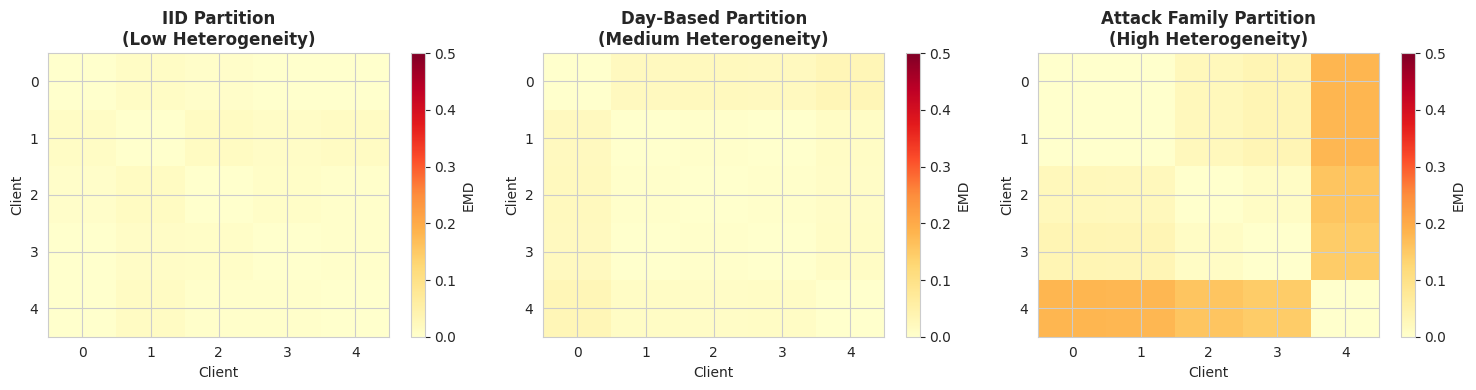

✓ EMD comparison plot saved


In [9]:
# Compare EMD across all strategies
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# IID EMD
im1 = axes[0].imshow(iid_emd, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.5)
axes[0].set_title('IID Partition\n(Low Heterogeneity)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Client')
axes[0].set_ylabel('Client')
plt.colorbar(im1, ax=axes[0], label='EMD')

# Day-based EMD
im2 = axes[1].imshow(day_emd, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.5)
axes[1].set_title('Day-Based Partition\n(Medium Heterogeneity)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Client')
axes[1].set_ylabel('Client')
plt.colorbar(im2, ax=axes[1], label='EMD')

# Family-based EMD
try:
    im3 = axes[2].imshow(family_emd, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.5)
    axes[2].set_title('Attack Family Partition\n(High Heterogeneity)', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Client')
    axes[2].set_ylabel('Client')
    plt.colorbar(im3, ax=axes[2], label='EMD')
except:
    axes[2].text(0.5, 0.5, 'Family partition\nnot available', 
                ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_title('Attack Family Partition\n(High Heterogeneity)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/plots/emd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ EMD comparison plot saved")

In [10]:
# Summary statistics
print("\n" + "="*70)
print("SUMMARY: PARTITIONING HETEROGENEITY")
print("="*70)

summaries = {
    'IID': iid_emd[np.triu_indices_from(iid_emd, k=1)].mean(),
    'Day-Based': day_emd[np.triu_indices_from(day_emd, k=1)].mean(),
}

if 'family_emd' in locals():
    summaries['Attack Family'] = family_emd[np.triu_indices_from(family_emd, k=1)].mean()

print("\nMean EMD (higher = more heterogeneous/non-IID):\n")
for strategy, mean_emd in sorted(summaries.items(), key=lambda x: x[1]):
    bar = "█" * int(mean_emd * 100)
    print(f"  {strategy:20s}: {mean_emd:.4f}  {bar}")

print("\n" + "="*70)
print("✓ All tests completed successfully!")
print("="*70)


SUMMARY: PARTITIONING HETEROGENEITY

Mean EMD (higher = more heterogeneous/non-IID):

  IID                 : 0.0068  
  Day-Based           : 0.0122  █
  Attack Family       : 0.0785  ███████

✓ All tests completed successfully!
